## AirBnB listing project 2024

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
data = pd.read_csv("datasets.csv",encoding_errors='ignore')


In [ ]:
data.head()

In [ ]:
data.tail()

In [ ]:
data.shape

In [12]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20770 entries, 0 to 20769
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20770 non-null  float64
 1   name                            20770 non-null  str    
 2   host_id                         20770 non-null  int64  
 3   host_name                       20770 non-null  str    
 4   neighbourhood_group             20770 non-null  str    
 5   neighbourhood                   20763 non-null  str    
 6   latitude                        20763 non-null  float64
 7   longitude                       20763 non-null  float64
 8   room_type                       20763 non-null  str    
 9   price                           20736 non-null  float64
 10  minimum_nights                  20763 non-null  float64
 11  number_of_reviews               20763 non-null  float64
 12  last_review                     20763 non-n

In [13]:
data.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,beds
count,2.077000e+04,2.077000e+04,20763.000000,20763.000000,20736.000000,20763.000000,20763.000000,20763.000000,20763.000000,20763.000000,20763.000000,20770.000000
mean,3.033858e+17,1.749049e+08,40.726821,-73.939179,187.714940,28.558493,42.610605,1.257589,18.866686,206.067957,10.848962,1.723592
std,3.901221e+17,1.725657e+08,0.060293,0.061403,1023.245124,33.532697,73.523401,1.904472,70.921443,135.077259,21.354876,1.211993
min,2.595000e+03,1.678000e+03,40.500314,-74.249840,10.000000,1.000000,1.000000,0.010000,1.000000,0.000000,0.000000,1.000000
25%,2.707260e+07,2.041184e+07,40.684159,-73.980755,80.000000,30.000000,4.000000,0.210000,1.000000,87.000000,1.000000,1.000000
50%,4.992852e+07,1.086990e+08,40.722890,-73.949597,125.000000,30.000000,14.000000,0.650000,2.000000,215.000000,3.000000,1.000000
75%,7.220000e+17,3.143997e+08,40.763106,-73.917475,199.000000,30.000000,49.000000,1.800000,5.000000,353.000000,15.000000,2.000000
max,1.050000e+18,5.504035e+08,40.911147,-73.713650,100000.000000,1250.000000,1865.000000,75.490000,713.000000,365.000000,1075.000000,42.000000


In [14]:
data.isnull().sum()

id                                 0
name                               0
host_id                            0
host_name                          0
neighbourhood_group                0
neighbourhood                      7
latitude                           7
longitude                          7
room_type                          7
price                             34
minimum_nights                     7
number_of_reviews                  7
last_review                        7
reviews_per_month                  7
calculated_host_listings_count     7
availability_365                   7
number_of_reviews_ltm              7
license                            0
rating                             0
bedrooms                           0
beds                               0
baths                              0
dtype: int64

In [9]:
data["latitude"] = data["latitude"].fillna(data["latitude"].mean())
data["longitude"] = data["longitude"].fillna(data["longitude"].mean())

data["minimum_nights"] = data["minimum_nights"].fillna(
    data["minimum_nights"].median()
)

data["number_of_reviews"] = data["number_of_reviews"].fillna(
    data["number_of_reviews"].median()
)

data["reviews_per_month"] = data["reviews_per_month"].fillna(
    data["reviews_per_month"].median()
)

data["calculated_host_listings_count"] = data[
    "calculated_host_listings_count"
].fillna(data["calculated_host_listings_count"].median())

data["availability_365"] = data["availability_365"].fillna(
    data["availability_365"].median()
)

data["price"] = data["price"].fillna(data["price"].median())

In [10]:
data.isnull().sum()

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     7
latitude                          0
longitude                         0
room_type                         7
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       7
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
number_of_reviews_ltm             7
license                           0
rating                            0
bedrooms                          0
beds                              0
baths                             0
dtype: int64

In [11]:
data.dropna(subset=["room_type", "last_review", "neighbourhood"], inplace=True)

In [12]:
data.isnull().sum()

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
number_of_reviews_ltm             0
license                           0
rating                            0
bedrooms                          0
beds                              0
baths                             0
dtype: int64

In [34]:
data.shape

(20763, 22)

In [13]:
data.duplicated().sum()
data[data.duplicated()]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,rating,bedrooms,beds,baths
6,4.527754e+07,Rental unit in New York · ★4.67 · 2 bedrooms ·...,51501835,Jeniffer,Manhattan,Hell's Kitchen,40.766610,-73.988100,Entire home/apt,144.0,...,01/05/23,0.24,139.0,364.0,2.0,No License,4.67,2,1,1
7,9.710000e+17,Rental unit in New York · ★4.17 · 1 bedroom · ...,528871354,Joshua,Manhattan,Chelsea,40.750764,-73.994605,Entire home/apt,187.0,...,18/12/23,1.67,1.0,343.0,6.0,Exempt,4.17,1,2,1
8,3.857863e+06,Rental unit in New York · ★4.64 · 1 bedroom · ...,19902271,John And Catherine,Manhattan,Washington Heights,40.835600,-73.942500,Private room,120.0,...,17/09/23,1.38,2.0,363.0,12.0,No License,4.64,1,1,1
9,4.089661e+07,Condo in New York · ★4.91 · Studio · 1 bed · 1...,61391963,Stay With Vibe,Manhattan,Murray Hill,40.751120,-73.978600,Entire home/apt,85.0,...,03/12/23,0.24,133.0,335.0,3.0,No License,4.91,Studio,1,1
10,4.958498e+07,Rental unit in New York · ★5.0 · 1 bedroom · 1...,51501835,Jeniffer,Manhattan,Hell's Kitchen,40.759950,-73.992960,Entire home/apt,115.0,...,29/07/23,0.16,139.0,276.0,2.0,No License,5,1,1,1
20736,7.990000e+17,Rental unit in New York · 2 bedrooms · 2 beds ...,224733902,CozySuites Copake,Manhattan,Upper East Side,40.768970,-73.957592,Entire home/apt,153.0,...,15/09/23,0.41,8.0,308.0,2.0,No License,No rating,2,2,2
20737,5.930000e+17,Rental unit in New York · ★4.79 · 2 bedrooms ·...,23219783,Rob,Manhattan,West Village,40.730220,-74.002910,Entire home/apt,175.0,...,22/11/23,2.03,4.0,129.0,25.0,No License,4.79,2,2,1
20738,9.230000e+17,Loft in New York · ★4.33 · 1 bedroom · 2 beds ...,520265731,Rodrigo,Manhattan,Greenwich Village,40.728390,-73.999540,Entire home/apt,156.0,...,02/01/24,2.60,1.0,356.0,9.0,Exempt,4.33,1,2,1
20739,1.336161e+07,Rental unit in New York · ★4.89 · 2 bedrooms ·...,8961407,Jamie,Manhattan,Harlem,40.805700,-73.946250,Entire home/apt,397.0,...,08/09/23,1.08,3.0,274.0,3.0,No License,4.89,2,2,1
20740,5.119566e+07,Rental unit in New York · Studio · 1 bed · 1 bath,51501835,Jeniffer,Manhattan,Chinatown,40.718360,-73.995850,Entire home/apt,100.0,...,25/05/23,0.08,139.0,306.0,1.0,No License,No rating,Studio,1,1


In [14]:
data.drop_duplicates(inplace=True)

In [15]:
data[data.duplicated()]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,rating,bedrooms,beds,baths


In [43]:
data.dtypes

id                                 object
name                                  str
host_id                             int64
host_name                             str
neighbourhood_group                   str
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                             float64
minimum_nights                    float64
number_of_reviews                 float64
last_review                           str
reviews_per_month                 float64
calculated_host_listings_count    float64
availability_365                  float64
number_of_reviews_ltm             float64
license                               str
rating                                str
bedrooms                              str
beds                                int64
baths                                 str
dtype: object

In [16]:
data['id']=data['id'].astype(object)
data['host_id']=data['host_id'].astype(object)
data.dtypes

id                                 object
name                                  str
host_id                            object
host_name                             str
neighbourhood_group                   str
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                             float64
minimum_nights                    float64
number_of_reviews                 float64
last_review                           str
reviews_per_month                 float64
calculated_host_listings_count    float64
availability_365                  float64
number_of_reviews_ltm             float64
license                               str
rating                                str
bedrooms                              str
beds                                int64
baths                                 str
dtype: object

# Univariate Analaysis

<Axes: xlabel='price'>

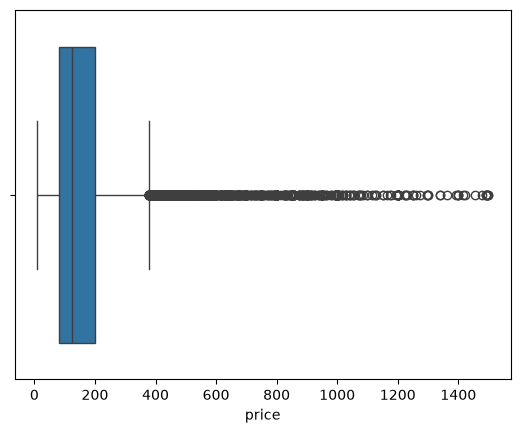

In [17]:
df= data[data["price"]<1500]

sns.boxplot(data=df,x='price')

Text(0, 0.5, 'frequency')

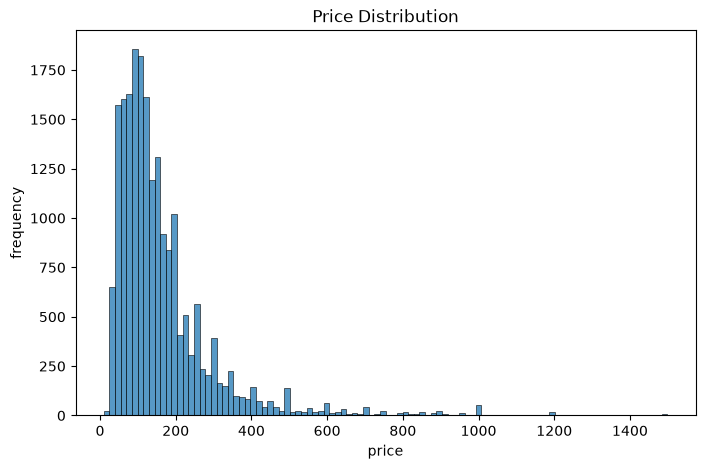

In [18]:
plt.figure(figsize=(8,5))
plt.title('Price Distribution')
sns.histplot(data=df ,x= 'price',bins =100)
plt.ylabel("frequency")

In [63]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'number_of_reviews_ltm', 'license', 'rating',
       'bedrooms', 'beds', 'baths'],
      dtype='str')

Text(0, 0.5, 'frequency')

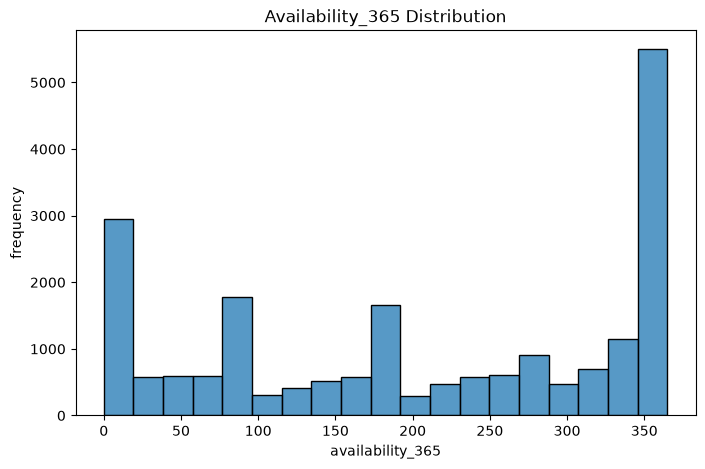

In [19]:
plt.figure(figsize=(8,5))
plt.title('Availability_365 Distribution')
sns.histplot(data=df ,x= "availability_365")
plt.ylabel("frequency")

Text(0, 0.5, 'frequency')

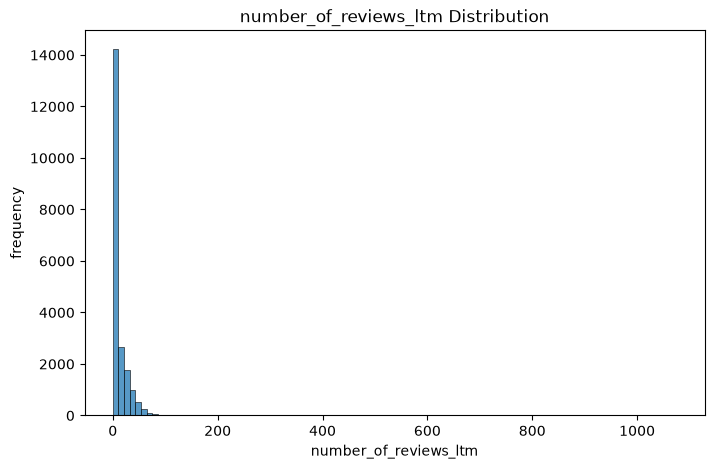

In [20]:
plt.figure(figsize=(8,5))
plt.title('number_of_reviews_ltm Distribution')
sns.histplot(data=df ,x= 'number_of_reviews_ltm',bins=100)
plt.ylabel("frequency")

In [21]:
df.groupby(by = "neighbourhood_group")['price'].mean()

neighbourhood_group
Bronx            107.990506
Brooklyn         155.056111
Manhattan        204.106287
Queens           121.683706
Staten Island    118.780069
Name: price, dtype: float64

# Feature Engineering

In [22]:
df["price_per_bed"] = df["price"]/df["beds"]
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,rating,bedrooms,beds,baths,price_per_bed
0,1312228.0,Rental unit in Brooklyn · ★5.0 · 1 bedroom,7130382,Walter,Brooklyn,Clinton Hill,40.683710,-73.964610,Private room,55.0,...,0.03,1.0,0.0,0.0,No License,5,1,1,Not specified,55.0
1,45277537.0,Rental unit in New York · ★4.67 · 2 bedrooms ·...,51501835,Jeniffer,Manhattan,Hell's Kitchen,40.766610,-73.988100,Entire home/apt,144.0,...,0.24,139.0,364.0,2.0,No License,4.67,2,1,1,144.0
2,971000000000000000.0,Rental unit in New York · ★4.17 · 1 bedroom · ...,528871354,Joshua,Manhattan,Chelsea,40.750764,-73.994605,Entire home/apt,187.0,...,1.67,1.0,343.0,6.0,Exempt,4.17,1,2,1,93.5
3,3857863.0,Rental unit in New York · ★4.64 · 1 bedroom · ...,19902271,John And Catherine,Manhattan,Washington Heights,40.835600,-73.942500,Private room,120.0,...,1.38,2.0,363.0,12.0,No License,4.64,1,1,1,120.0
4,40896611.0,Condo in New York · ★4.91 · Studio · 1 bed · 1...,61391963,Stay With Vibe,Manhattan,Murray Hill,40.751120,-73.978600,Entire home/apt,85.0,...,0.24,133.0,335.0,3.0,No License,4.91,Studio,1,1,85.0


In [23]:
df.groupby(by ="neighbourhood_group")["price_per_bed"].mean()

neighbourhood_group
Bronx             74.713639
Brooklyn          99.778788
Manhattan        138.679888
Queens            76.362123
Staten Island     67.728101
Name: price_per_bed, dtype: float64

# bivariate analysis

In [31]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'number_of_reviews_ltm', 'license', 'rating',
       'bedrooms', 'beds', 'baths', 'price_per_bed'],
      dtype='str')

<Axes: xlabel='neighbourhood_group', ylabel='price'>

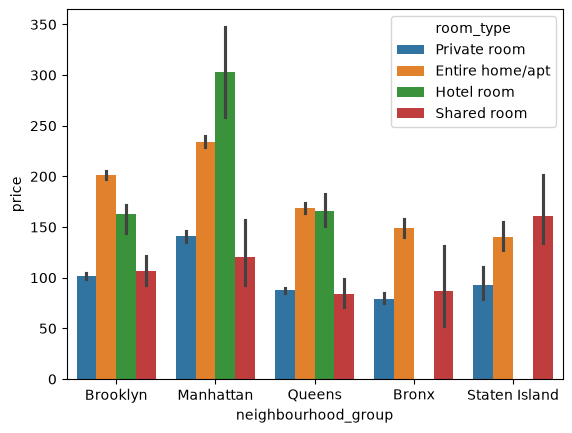

In [32]:
sns.barplot(data=df,x='neighbourhood_group',y="price",hue="room_type")

<Axes: title={'center': 'Locality and Review Dependency'}, xlabel='number_of_reviews', ylabel='price'>

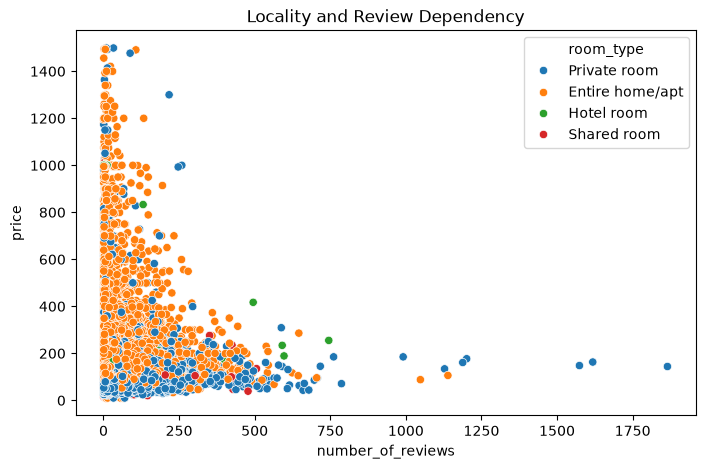

In [33]:
plt.figure(figsize=(8,5))
plt.title("Locality and Review Dependency")
sns.scatterplot(data = df,x="number_of_reviews",y="price",hue="room_type")

In [39]:
df.dtypes

id                                 object
name                                  str
host_id                            object
host_name                             str
neighbourhood_group                   str
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                             float64
minimum_nights                    float64
number_of_reviews                 float64
last_review                           str
reviews_per_month                 float64
calculated_host_listings_count    float64
availability_365                  float64
number_of_reviews_ltm             float64
license                               str
rating                                str
bedrooms                              str
beds                                int64
baths                                 str
price_per_bed                     float64
dtype: object

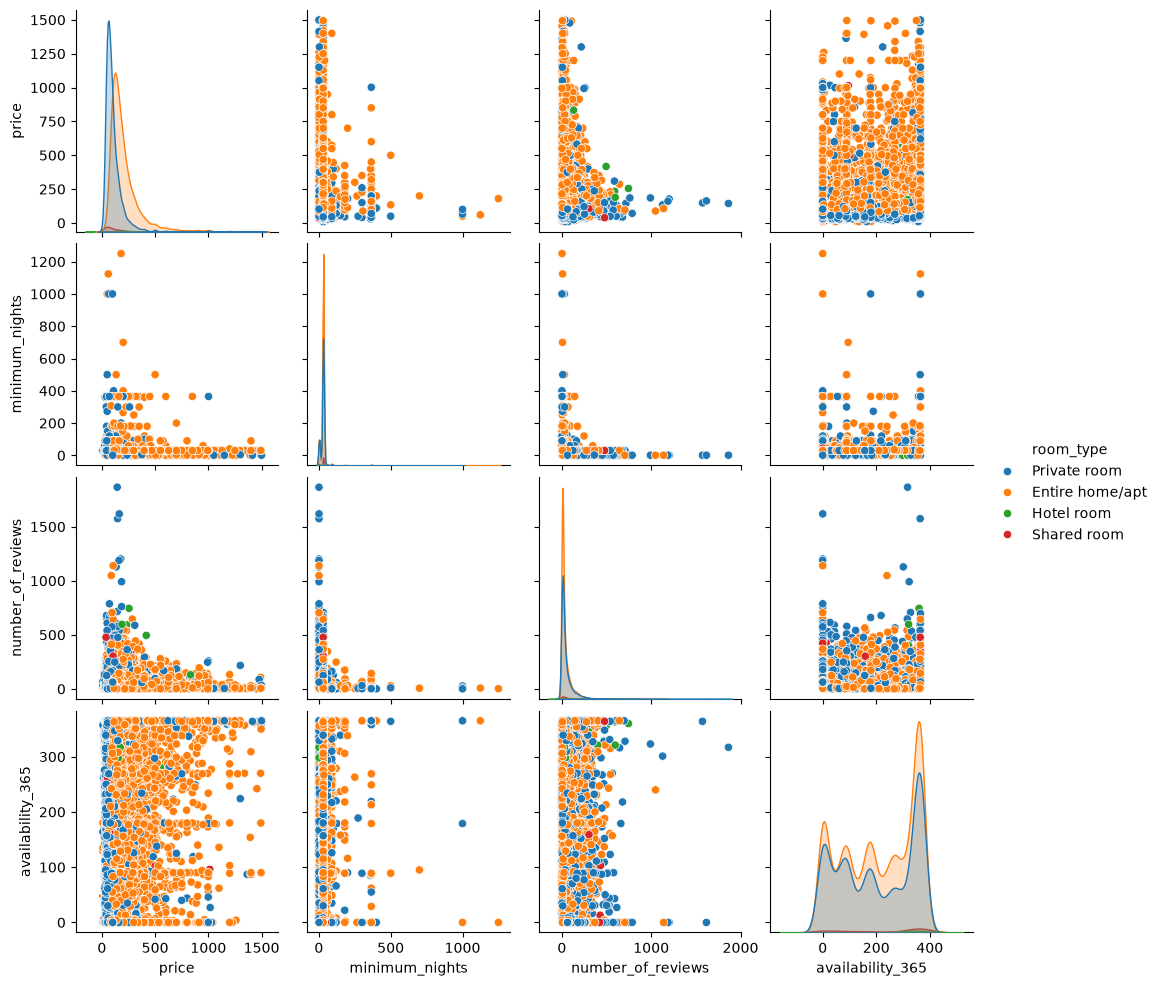

In [48]:
sns.pairplot(data=df,vars=['price','minimum_nights','number_of_reviews','availability_365'],hue="room_type")

<Axes: title={'center': 'Geographic Distribution of Airbnb Listing'}, xlabel='longitude', ylabel='latitude'>

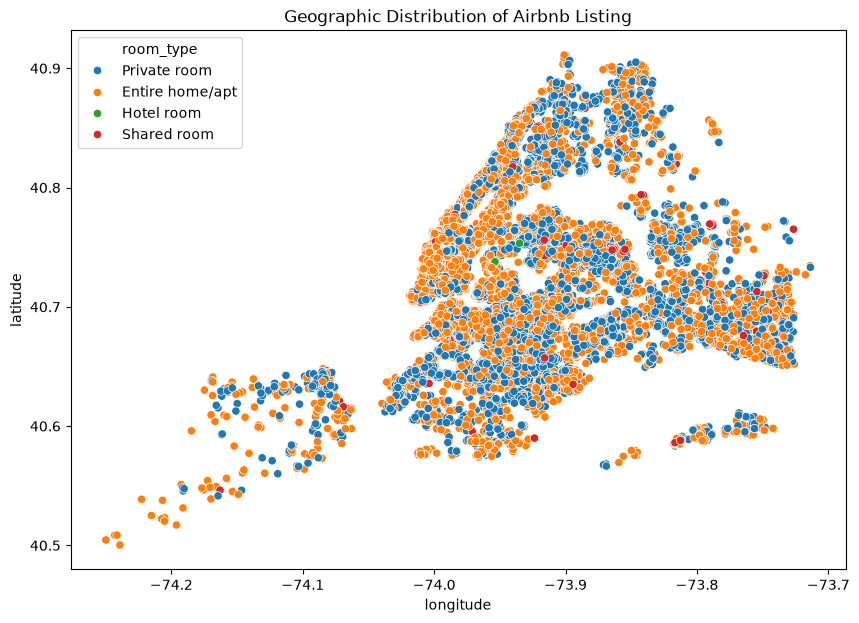

In [46]:
plt.figure(figsize=(10,7))
plt.title("Geographic Distribution of Airbnb Listing")
sns.scatterplot(data=df,x='longitude',y='latitude',hue='room_type')

In [49]:
 df.columns


Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'number_of_reviews_ltm', 'license', 'rating',
       'bedrooms', 'beds', 'baths', 'price_per_bed'],
      dtype='str')

In [ ]:
corr = df[['latitude','longitude','minimum_nights','number_of_reviews','number_of_reviews_ltm','availability_365','beds']]
corr
plt.figure(figsize=(8,6))
sns.heatmap(data=corr,annot=True)